# eDNA Metabarcoding Pipeline Analysis: Lake Geneva
### A Reproducible Workflow for MinION Amplicon Sequencing (18S & COI)
**Project:** Genorobotics Semester Project (EPFL)

**Marker:** 18S rRNA (Eukaryotic Biodiversity) & COI (Metazoan Target)

## 0. Critical Review: Limitations & Technical Constraints

Before presenting the biological results, I want to be honest about the technical limitations I encountered during this project. 
### 1. The COI Failure: Short Reads and Biological Swamping
While the 18S marker was successful, the COI marker did not perform as expected. 
* **Data Loss:** After pre-processing, I realized that over 90 percent of the raw COI reads were shorter than 300 base pairs. These are likely primer dimers or highly degraded DNA fragments. My pipeline correctly filtered these out to maintain data quality, but it left me with very few reads to analyze.
* **Lack of Specificity:** The few COI sequences that remained were mostly identified as ciliates rather than vertebrates. I believe ciliate DNA is so abundant in lake water that it effectively swamped the primers, preventing them from catching the rarer fish DNA we were looking for.

### 2. Taxonomic Gaps and the Choice of Accuracy
There are two reasons why the taxonomic results might look "imperfect" at first glance:
* **The Brazilian Bee Effect:** You will see assignments for exotic species like *Frieseomelitta* (a Brazilian bee) or *Gluvia* (an Iberian spider). This is a known database gap. The SILVA database lacks many local Swiss terrestrial sequences, so the algorithm simply identifies the closest genetic relative it can find.
* **The Unassigned Rate:** I deliberately kept a high confidence threshold of 0.8 for all assignments. While this results in many "Unassigned" rows at the species level, I believe it is better to be conservative. I would rather label a sequence as unknown than provide a false identification for a species that is not actually present in the lake.

### 3. Clustering and Size Selection Logic
I made specific decisions during the bioinformatic processing to ensure the results remained robust:
* **95 Percent Identity:** Because Nanopore sequencing has a raw error rate of around 5 percent, I clustered the sequences at 95 percent identity. If I had used a stricter threshold (like 99 percent), the sequencing errors would have been interpreted as thousands of "fake" new species.
* **The 18S Size Filter:** I discarded all 18S reads longer than 3000 base pairs. Since our target region is approximately 1800 base pairs, anything much longer is usually a concatemer (two DNA molecules fused together during library preparation). Including them would have artificially inflated the abundance counts for certain taxa.

### 4. Computational and Database Needs
The Global Clustering step was the primary bottleneck, taking up over 50 percent of the total runtime. With current data, it took around ~40 minutes to process the full pipeline.

## To-Do List for Future Work
I think there is still a lot of work to do to make this pipeline truly robust for lake monitoring. If I were to continue this project next semester, here are the specific improvements I would focus on:

* **Troubleshoot the COI yield:** I want to look into why 90 percent of the COI reads were too short. I suspect this is a PCR artifact but maybe we can play with parameters in the pipeline (size selection, etc.).
* **Design blocking primers:** Since my BLAST results showed that ciliates were the main competitor for the COI primers, lab team could implement a blocking primer. This would specifically target ciliate DNA and prevent it from amplifying, which would give rare fish or mussel DNA a better chance to be detected.
* **Create a local reference library:** I need to build a custom database for the lake. By gathering sequences for local fish, insects, and plants from NCBI, I could avoid the "Brazilian Bee" artifacts and get much more accurate species identifications.
* **Improve the clustering efficiency:** I would add a dereplication step before the global clustering. This would group identical sequences together early on, which would save a lot of time during the VSEARCH step and allow the pipeline to handle more samples at once.

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from pathlib import Path
from Bio import SeqIO
from matplotlib import cm

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'figure.dpi': 150,        
    'savefig.dpi': 300,       
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Define a function to clean sample names (e.g., "Sample_barcode01" -> "01")
def clean_sample_names(columns):
    return [c.replace('Sample_barcode', '').replace('Sample_', '') for c in columns]

# Auto-detect taxonomy column prefix (SILVA_ or MIDORI_)
def get_tax_prefix(df):
    for col in df.columns:
        if col.startswith("SILVA_"):
            return "SILVA"
        if col.startswith("MIDORI2_"):
            return "MIDORI2"
        if col.startswith("MIDORI_"):
            return "MIDORI"
    return "SILVA"

BASE = Path("out/Water_eDNA_18S_COI_14_01_26")

# Global confidence threshold for taxonomy filtering
CONF_THRESHOLD = 0.8

## Table Headers & Data Structure
Inspect the comprehensive taxonomy CSV files to verify column names and data shape.

In [98]:
# Load both datasets
df_18s = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_18S.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/comprehensive_taxonomy_COI.csv')

prefix_18s = get_tax_prefix(df_18s)
prefix_coi = get_tax_prefix(df_coi_raw)

for label, df, pfx in [("18S", df_18s, prefix_18s), ("COI", df_coi_raw, prefix_coi)]:
    print(f"\n{'='*60}")
    print(f"  {label} ({pfx} database)  —  {df.shape[0]} OTUs × {df.shape[1]} columns")
    print(f"{'='*60}")
    
    sample_cols = [c for c in df.columns if c.startswith("Sample_")]
    taxonomy_cols = [c for c in df.columns if c.startswith(f"{pfx}_") or c.startswith("NCBI_")]
    meta_cols = [c for c in df.columns if c not in sample_cols + taxonomy_cols]
    
    print(f"\nMetadata columns:  {meta_cols}")
    print(f"Sample columns:    {sample_cols}")
    print(f"Taxonomy columns:  {taxonomy_cols}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))


  18S (SILVA database)  —  59002 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['SILVA_Domain', 'SILVA_Domain_Conf', 'SILVA_Phylum', 'SILVA_Phylum_Conf', 'SILVA_Class', 'SILVA_Class_Conf', 'SILVA_Order', 'SILVA_Order_Conf', 'SILVA_Family', 'SILVA_Family_Conf', 'SILVA_Genus', 'SILVA_Genus_Conf', 'SILVA_Species', 'SILVA_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,SILVA_Order_Conf,SILVA_Family,SILVA_Family_Conf,SILVA_Genus,SILVA_Genus_Conf,SILVA_Species,SILVA_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_18S_005421,0.766523,1,0.004390,0.095702,0.082278,0.099657,0.0,0.0,0.006094,...,1.0,Oligotrichia,1.0,Strombidium,1.0,NaN,NaN,NaN,NaN,NaN
1,OTU_18S_000035,0.355367,2,0.020870,0.021060,0.004128,0.006171,0.0,0.0,0.028086,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OTU_18S_000362,0.310807,3,0.008224,0.016476,0.003853,0.005794,0.0,0.0,0.010984,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  COI (MIDORI2 database)  —  6281 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['MIDORI2_Domain', 'MIDORI2_Domain_Conf', 'MIDORI2_Phylum', 'MIDORI2_Phylum_Conf', 'MIDORI2_Class', 'MIDORI2_Class_Conf', 'MIDORI2_Order', 'MIDORI2_Order_Conf', 'MIDORI2_Family', 'MIDORI2_Family_Conf', 'MIDORI2_Genus', 'MIDORI2_Genus_Conf', 'MIDORI2_Species', 'MIDORI2_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,MIDORI2_Order_Conf,MIDORI2_Family,MIDORI2_Family_Conf,MIDORI2_Genus,MIDORI2_Genus_Conf,MIDORI2_Species,MIDORI2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000076,0.279448,1,0.021097,0.040323,0.042105,0.008237,0.0,0.0,0.01108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OTU_COI_005155,0.166667,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OTU_COI_005391,0.166667,3,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Confidence Distribution Dashboard

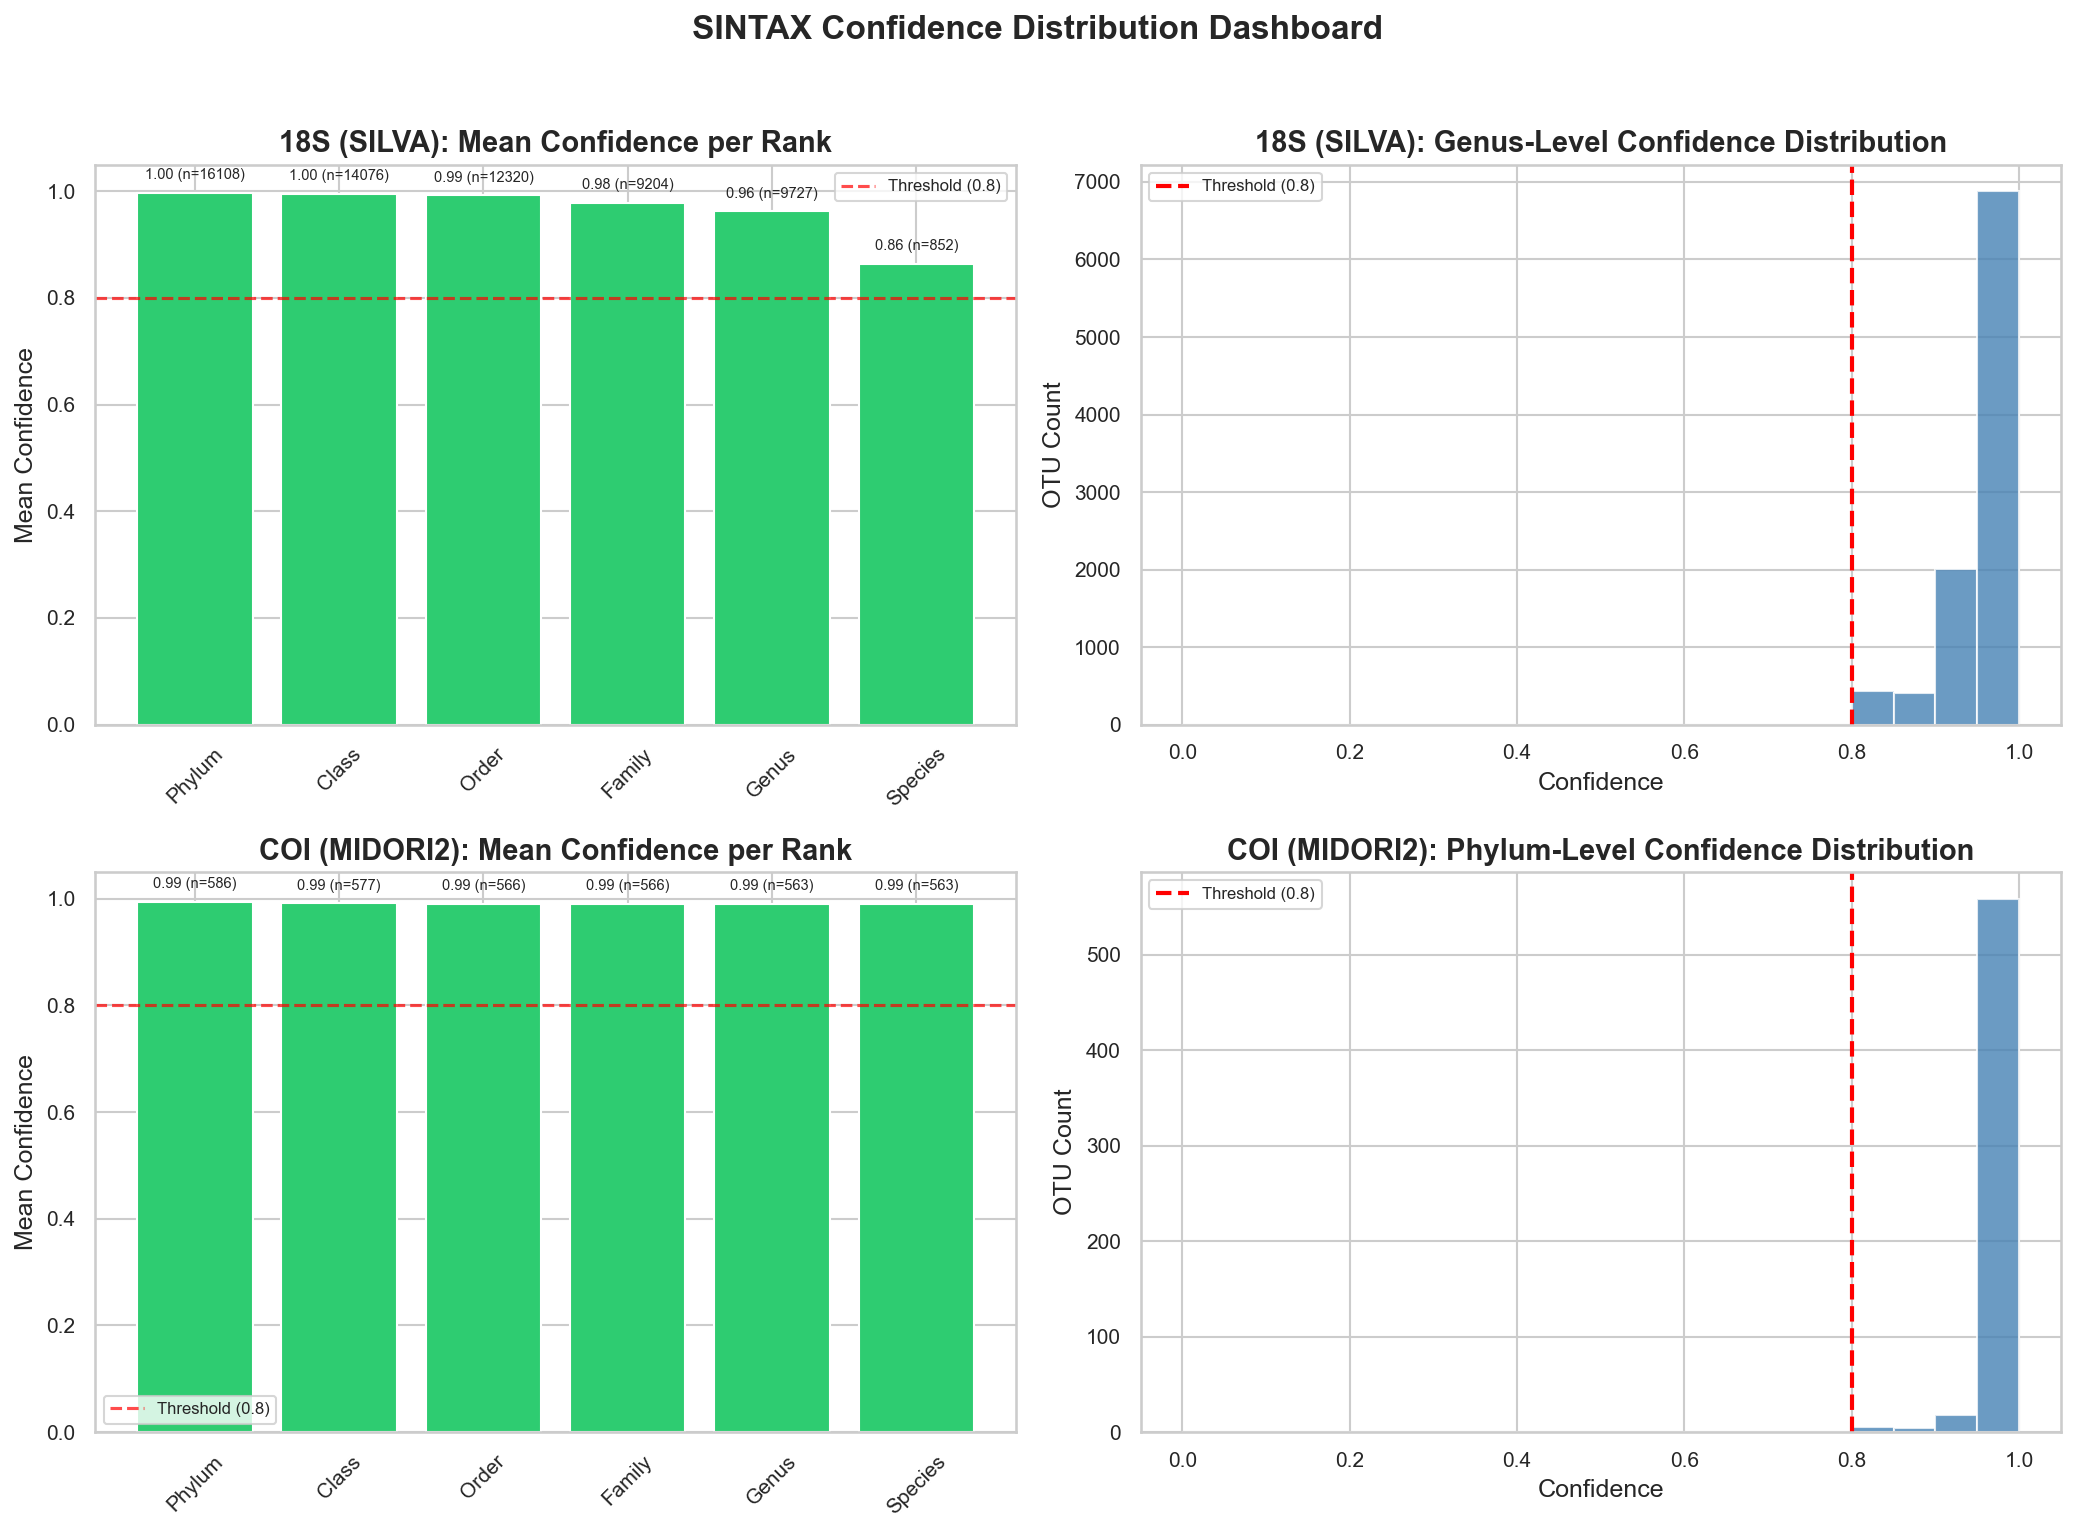

In [99]:
# === SINTAX Confidence Distribution Dashboard ===
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

def plot_confidence_row(df, prefix, marker_label, axes):
    """Plot confidence metrics for one marker."""
    conf_cols = [f'{prefix}_{r}_Conf' for r in ranks]
    existing = [c for c in conf_cols if c in df.columns]
    if not existing:
        for ax in axes:
            ax.text(0.5, 0.5, 'No confidence columns found.\nRegenerate with:\nbash regenerate_taxonomy.sh',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
            ax.set_title(marker_label)
        return

    means, counts = [], []
    for r in ranks:
        col = f'{prefix}_{r}_Conf'
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors='coerce').dropna()
            means.append(vals.mean() if len(vals) > 0 else 0)
            counts.append(len(vals))
        else:
            means.append(0)
            counts.append(0)

    ax1 = axes[0]
    colors = ['#2ecc71' if m >= 0.8 else '#e74c3c' for m in means]
    bars = ax1.bar(ranks, means, color=colors, edgecolor='white')
    ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Threshold (0.8)')
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('Mean Confidence')
    ax1.set_title(f'{marker_label}: Mean Confidence per Rank', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.tick_params(axis='x', rotation=45)
    for bar, m, n in zip(bars, means, counts):
        if m > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{m:.2f} (n={n})', ha='center', va='bottom', fontsize=7)

    hist_rank = 'Genus' if prefix == 'SILVA' else 'Phylum'
    hist_col = f'{prefix}_{hist_rank}_Conf'
    ax2 = axes[1]
    if hist_col in df.columns:
        vals = pd.to_numeric(df[hist_col], errors='coerce').dropna()
        if len(vals) > 0:
            ax2.hist(vals, bins=20, range=(0, 1), color='steelblue', edgecolor='white', alpha=0.8)
            ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Threshold (0.8)')
            ax2.set_xlabel('Confidence')
            ax2.set_ylabel('OTU Count')
            ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence Distribution', fontweight='bold')
            ax2.legend(fontsize=8)
        else:
            ax2.text(0.5, 0.5, f'No {hist_rank} confidence values',
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, f'Column {hist_col} not found',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence', fontweight='bold')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SINTAX Confidence Distribution Dashboard', fontsize=16, fontweight='bold', y=1.02)

plot_confidence_row(df_18s, prefix_18s, f'18S ({prefix_18s})', axes[0])
plot_confidence_row(df_coi_raw, prefix_coi, f'COI ({prefix_coi})', axes[1])

plt.tight_layout()
plt.show()

## Raw Read Length Distributions (Pre-Clustering)
Number of reads at each sequence length, aggregated across all barcodes for each marker. This reveals the actual abundance of reads by length before OTU clustering, highlighting primer dimers, truncated reads, or length biases in the sequencing run.

✓ 18S: 226,443 reads, median=1857bp, range=1500-2799bp
✓ COI: 14,495 reads, median=834bp, range=500-900bp


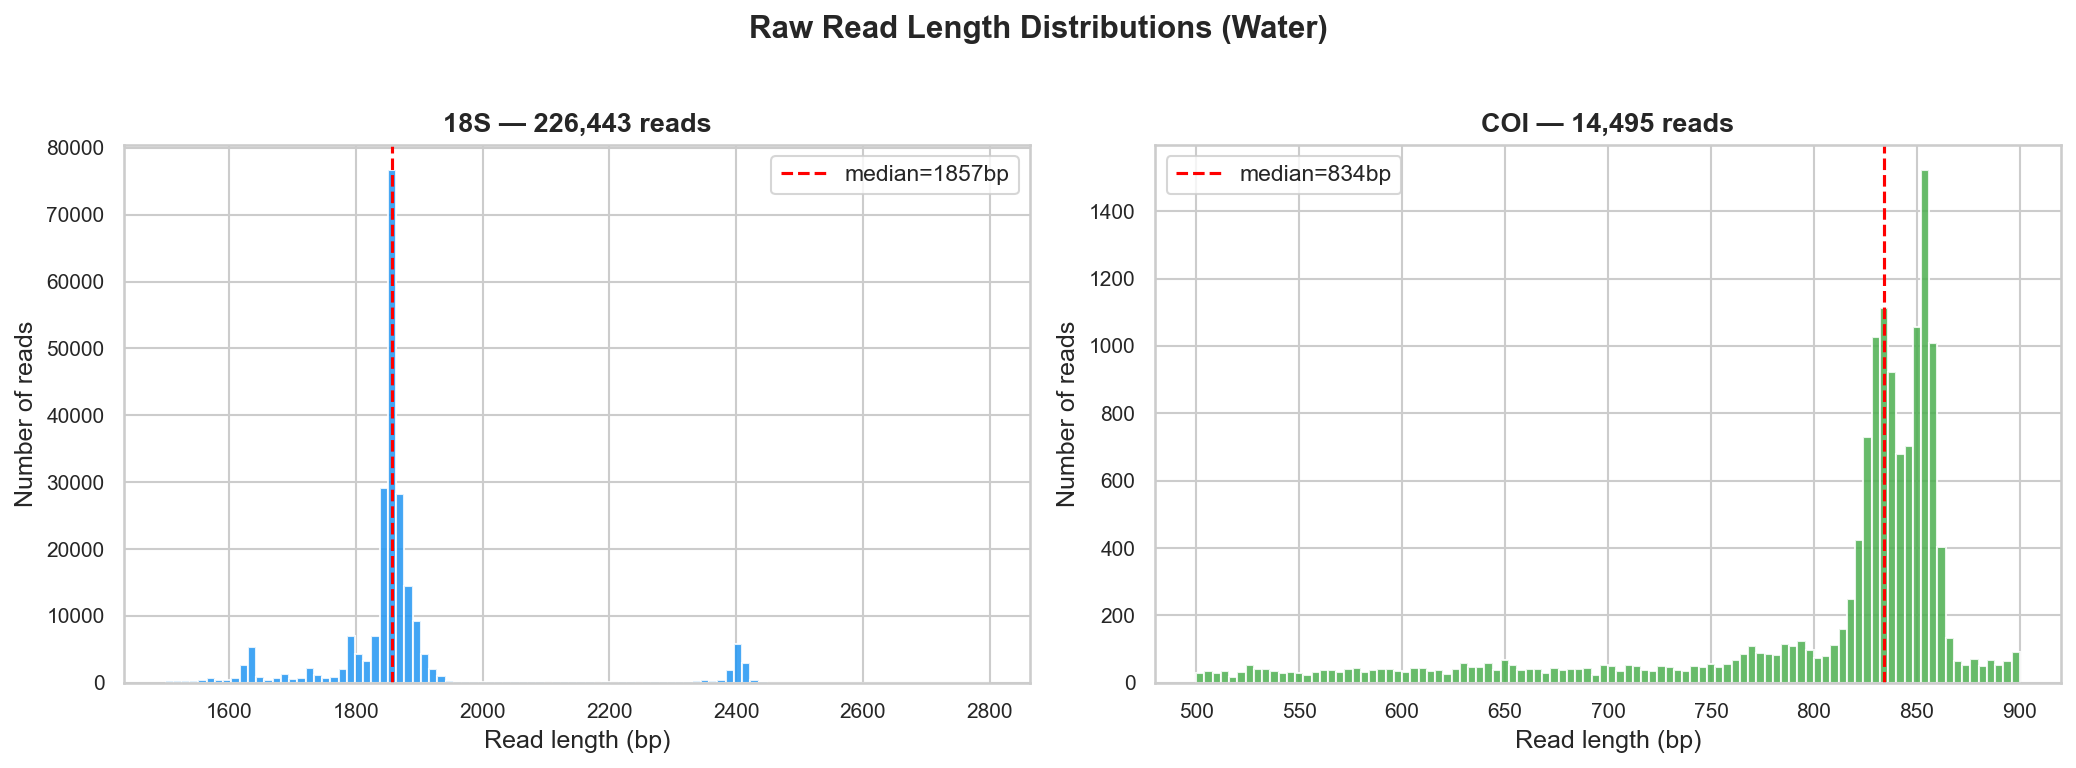

In [100]:
import gzip

# Collect raw read lengths per marker across all barcodes
barcode_dirs = sorted(BASE.glob("barcode*"))
marker_lengths = {"18S": [], "COI": []}
marker_colors_raw = {"18S": "#2196F3", "COI": "#4CAF50"}

for bd in barcode_dirs:
    for marker in marker_lengths:
        fq = bd / f"filtered_reads_{marker}.fastq.gz"
        if fq.exists():
            with gzip.open(str(fq), 'rt') as f:
                for i, line in enumerate(f):
                    if i % 4 == 1:  # sequence line
                        marker_lengths[marker].append(len(line.strip()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, lengths) in enumerate(marker_lengths.items()):
    ax = axes[i]
    if lengths:
        ax.hist(lengths, bins=100, color=marker_colors_raw[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} — {len(lengths):,} reads", fontsize=13, fontweight="bold")
        ax.set_xlabel("Read length (bp)")
        ax.set_ylabel("Number of reads")
        ax.legend()
        print(f"✓ {marker}: {len(lengths):,} reads, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nNo reads found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Raw Read Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Consensus OTU Sequence Length Distributions
Length distributions of consensus OTU sequences for each marker. Useful for identifying primer dimers, truncated reads, or off-target amplification.

✓ 18S: 35237 OTUs, median=1853bp, range=1500-2809bp
✓ COI: 4162 OTUs, median=829bp, range=417-902bp


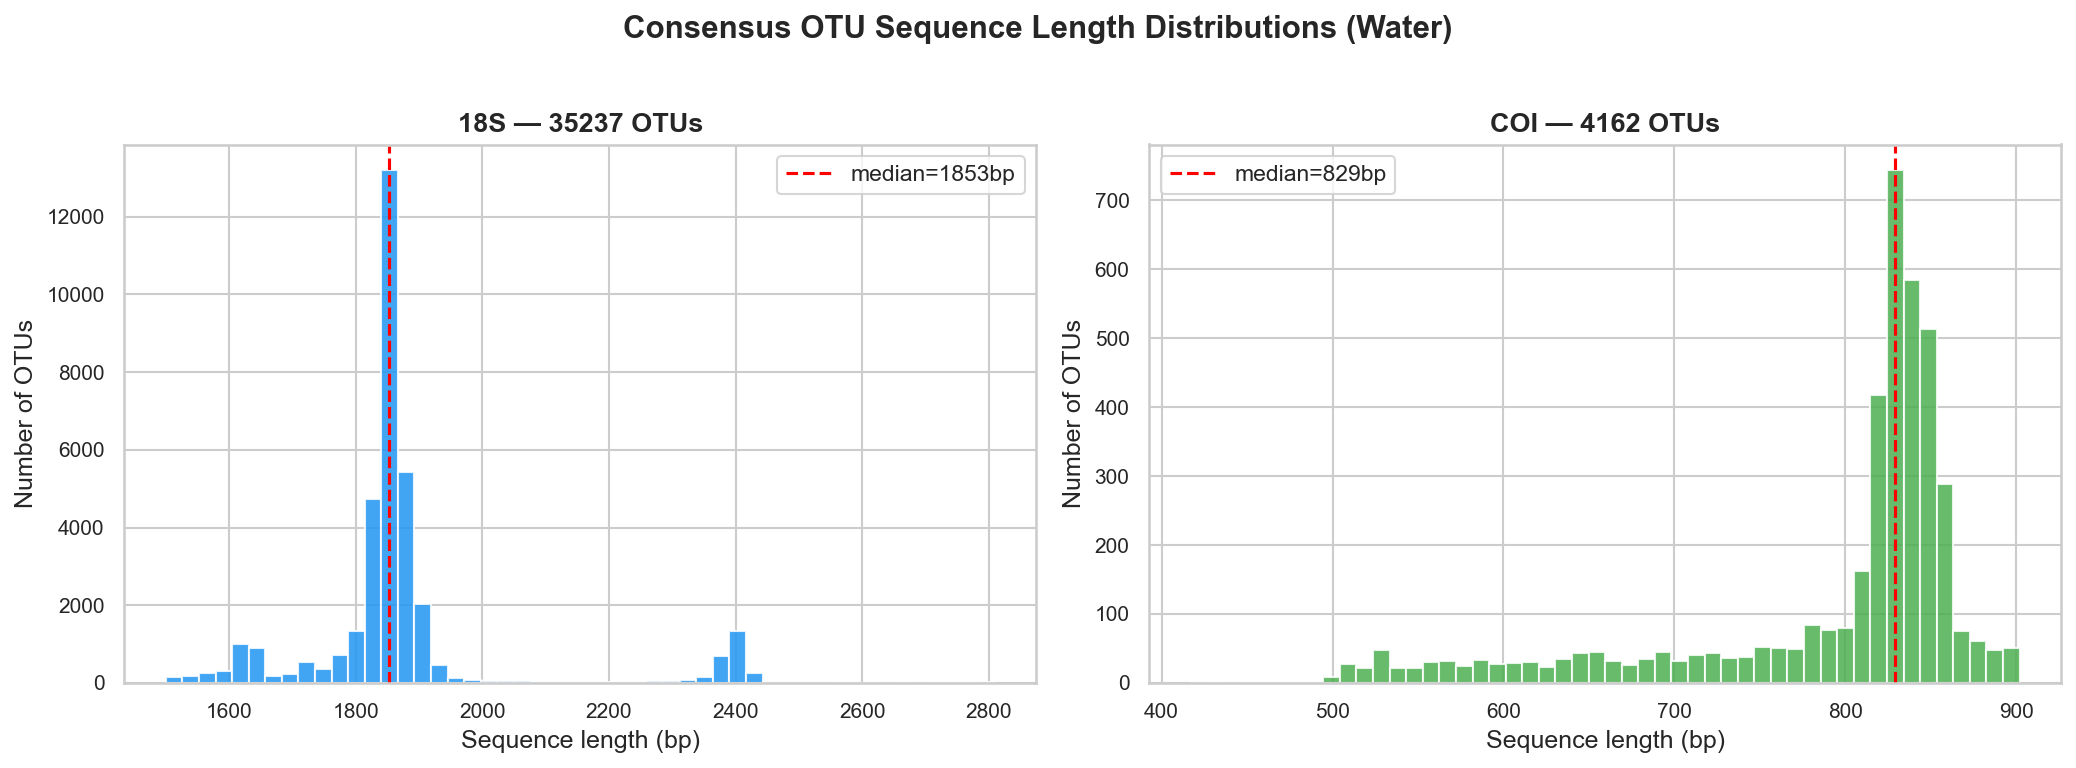

In [101]:
# Parse consensus FASTA files and plot sequence length distributions
fasta_files = {
    "18S": BASE / "temp_clustering/consensus_18S_clean.fasta",
    "COI": BASE / "temp_clustering/consensus_COI_clean.fasta",
}
marker_colors = {"18S": "#2196F3", "COI": "#4CAF50"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, path) in enumerate(fasta_files.items()):
    ax = axes[i]
    if path.exists():
        lengths = [len(rec.seq) for rec in SeqIO.parse(str(path), "fasta")]
        ax.hist(lengths, bins=50, color=marker_colors[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} — {len(lengths)} OTUs", fontsize=13, fontweight="bold")
        ax.set_xlabel("Sequence length (bp)")
        ax.set_ylabel("Number of OTUs")
        ax.legend()
        print(f"✓ {marker}: {len(lengths)} OTUs, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nFASTA not found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Consensus OTU Sequence Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Part A: 18S Marker Biodiversity Analysis
*Objective: To characterize the planktonic community structure and validate the bioinformatic pipeline using the 18S marker.*

## A.1.a Broad Taxonomic Structure
This stacked bar chart visualizes the relative abundance of eukaryotic Phyla across all samples.
* **Expected Result:** We expect to see high abundances of **Arthropoda** (Zooplankton) and **Ciliophora** (Microbial Loop).
* **Terrestrial Input:** Look for **Phragmoplastophyta** (Land Plants/Pollen).

In [102]:
# 18S Phylum-level plot (data already loaded above)
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
phylum_col_18s = f'{prefix_18s}_Phylum'

# Confidence filter: blank low-confidence phylum assignments
_phylum_conf = f'{prefix_18s}_Phylum_Conf'
if _phylum_conf in df_18s.columns:
    df_18s.loc[pd.to_numeric(df_18s[_phylum_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, phylum_col_18s] = ''
df_18s[phylum_col_18s] = df_18s[phylum_col_18s].fillna('Unassigned')
phylum_18s = df_18s.groupby(phylum_col_18s)[sample_cols_18s].sum()

# Sort and Group "Others"
phylum_18s['Total'] = phylum_18s.sum(axis=1)
phylum_18s = phylum_18s.sort_values('Total', ascending=False)
top_phyla = phylum_18s.head(10).index

plot_data = phylum_18s.loc[top_phyla].drop(columns='Total')
others = phylum_18s.loc[~phylum_18s.index.isin(top_phyla)].drop(columns='Total').sum()
plot_data.loc['Others'] = others

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data.columns = clean_sample_names(plot_data.columns)
plot_data.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Lake Community Composition — Phylum (18S, {prefix_18s})', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## A.1.b Class-Level Breakdown (18S)
**Objective:** To see which specific biological Classes dominate within the broad Phyla.

**Visual Analysis:**
1.  **Intramacronucleata (Ciliates):** The dominant Class, confirming the microbial loop signal.
2.  **Insecta (Terrestrial Input):** Arthropod reads at the class level reveal the source — most are insects (pollen, runoff), not aquatic crustaceans.
3.  **Branchiopoda (Zooplankton):** Look for this class — it includes Daphnia and validates aquatic sampling.

In [103]:
# Group by Class (18S)
class_col_18s = f'{prefix_18s}_Class'
# Confidence filter: blank low-confidence class assignments
_class_conf = f'{prefix_18s}_Class_Conf'
if _class_conf in df_18s.columns:
    df_18s.loc[pd.to_numeric(df_18s[_class_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, class_col_18s] = ''
df_18s[class_col_18s] = df_18s[class_col_18s].fillna('Unassigned')
class_18s = df_18s.groupby(class_col_18s)[sample_cols_18s].sum()
class_18s = class_18s.drop('Unassigned', errors='ignore')

# Sort and Top 15
class_18s['Total'] = class_18s.sum(axis=1)
class_18s = class_18s.sort_values('Total', ascending=False)
top_classes = class_18s.head(15).index

# Prepare Data
plot_cls = class_18s.loc[top_classes].drop(columns='Total')
others_cls = class_18s.loc[~class_18s.index.isin(top_classes)].drop(columns='Total').sum()
plot_cls.loc['Others'] = others_cls

# Custom color logic
num_colors = len(plot_cls)
colors = cm.tab20(np.linspace(0, 1, num_colors))
custom_colors = []
for i, cls_name in enumerate(plot_cls.index):
    if cls_name == 'Unassigned':
        custom_colors.append('#D3D3D3')
    elif cls_name == 'Others':
        custom_colors.append('#696969')
    else:
        custom_colors.append(colors[i])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_cls.columns = clean_sample_names(plot_cls.columns)
plot_cls = plot_cls.div(plot_cls.sum(axis=0), axis=1) * 100  # normalize to %
plot_cls = plot_cls.fillna(0)
plot_cls.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors)

ax.set_title(f'Class-Level Composition (18S, {prefix_18s})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Class')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_cls.columns):
    if plot_cls[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## A.2 Order-Level Breakdown (18S)

In [104]:
order_col_18s = f'{prefix_18s}_Order'
# Confidence filter: blank low-confidence order assignments
_order_conf = f'{prefix_18s}_Order_Conf'
if _order_conf in df_18s.columns:
    df_18s.loc[pd.to_numeric(df_18s[_order_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, order_col_18s] = ''
df_18s[order_col_18s] = df_18s[order_col_18s].fillna('Unassigned')
order_18s = df_18s.groupby(order_col_18s)[sample_cols_18s].sum()
order_18s = order_18s.drop('Unassigned', errors='ignore')

order_18s['Total'] = order_18s.sum(axis=1)
order_18s = order_18s.sort_values('Total', ascending=False)
top_orders_18s = order_18s.head(15).index

plot_ord_18s = order_18s.loc[top_orders_18s].drop(columns='Total')
others_ord_18s = order_18s.loc[~order_18s.index.isin(top_orders_18s)].drop(columns='Total').sum()
plot_ord_18s.loc['Others'] = others_ord_18s

fig, ax = plt.subplots(figsize=(12, 7))
plot_ord_18s.columns = clean_sample_names(plot_ord_18s.columns)
plot_ord_18s = plot_ord_18s.div(plot_ord_18s.sum(axis=0), axis=1) * 100  # normalize to %
plot_ord_18s = plot_ord_18s.fillna(0)
plot_ord_18s.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Order-Level Composition (18S, {prefix_18s})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
ax.legend(title='Order', bbox_to_anchor=(1.02, 1), loc='upper left')

for _idx, _sample in enumerate(plot_ord_18s.columns):
    if plot_ord_18s[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## A.3 Genus-Level Top 20 (18S)
Top genera detected by the 18S marker with confidence annotations.

In [ ]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_18s[genus_col] = df_18s[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_18s.columns:
    mask_conf = pd.to_numeric(df_18s[conf_col], errors='coerce') >= 0.8
    df_conf = df_18s[mask_conf].copy()
else:
    df_conf = df_18s[df_18s[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_18s].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.sum(axis=1)
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (18S, {prefix_18s})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

### Top 20 Genera by Abundance — All Confidences (18S)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

In [ ]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_tmp = df_18s.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_18s].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.sum(axis=1)
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Total Abundance', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (18S, {prefix_18s})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## A.4 The "Unassigned" Reality Check
**Limitation:** A significant portion of reads (especially at the family level) remain "Unassigned."

**Why does this happen?**
1.  **Database Gaps:** The SILVA database is excellent but not exhaustive.
2.  **Strict Thresholds:** We used a **confidence threshold of 0.8** in SINTAX. If the algorithm is not sure, it marks it as "Unassigned" rather than guessing wrong.
3.  **Methodological Choice:** We chose **Accuracy over Coverage**. We prefer to say "Unknown Ciliate" than to falsely identify it as a species that doesn't exist here. _**But it should definitely be investigated further in future work.**_

In [106]:
# Calculate % Unassigned at each level
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
levels_18s = [f'{prefix_18s}_{r}' for r in ranks]
unassigned_counts = []

for level in levels_18s:
    conf_level = level + '_Conf'
    no_taxonomy = df_18s[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_18s[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_18s.columns else pd.Series(False, index=df_18s.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_counts.append(pct)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=ranks, y=unassigned_counts, color="salmon")
plt.title('Taxonomic Resolution Decay (18S)', fontweight='bold')
plt.ylabel('% of OTUs Unassigned')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## A.5 Forensics: Manual BLAST Identification (18S)
BLAST validation of the top 18S OTUs provides ground-truth identification beyond what SINTAX can offer.
1. **Ciliate Confirmation:** We expect the top OTUs to be confirmed as uncultured ciliate clones, consistent with the SINTAX results.
2. **Daphnia Validation:** Look for *Daphnia galeata* — its presence via BLAST confirms the zooplankton signal seen in the genus-level analysis.
3. **Uncultured Eukaryotes:** Many top hits may be "Uncultured eukaryote clone," reflecting organisms not yet formally described in databases.

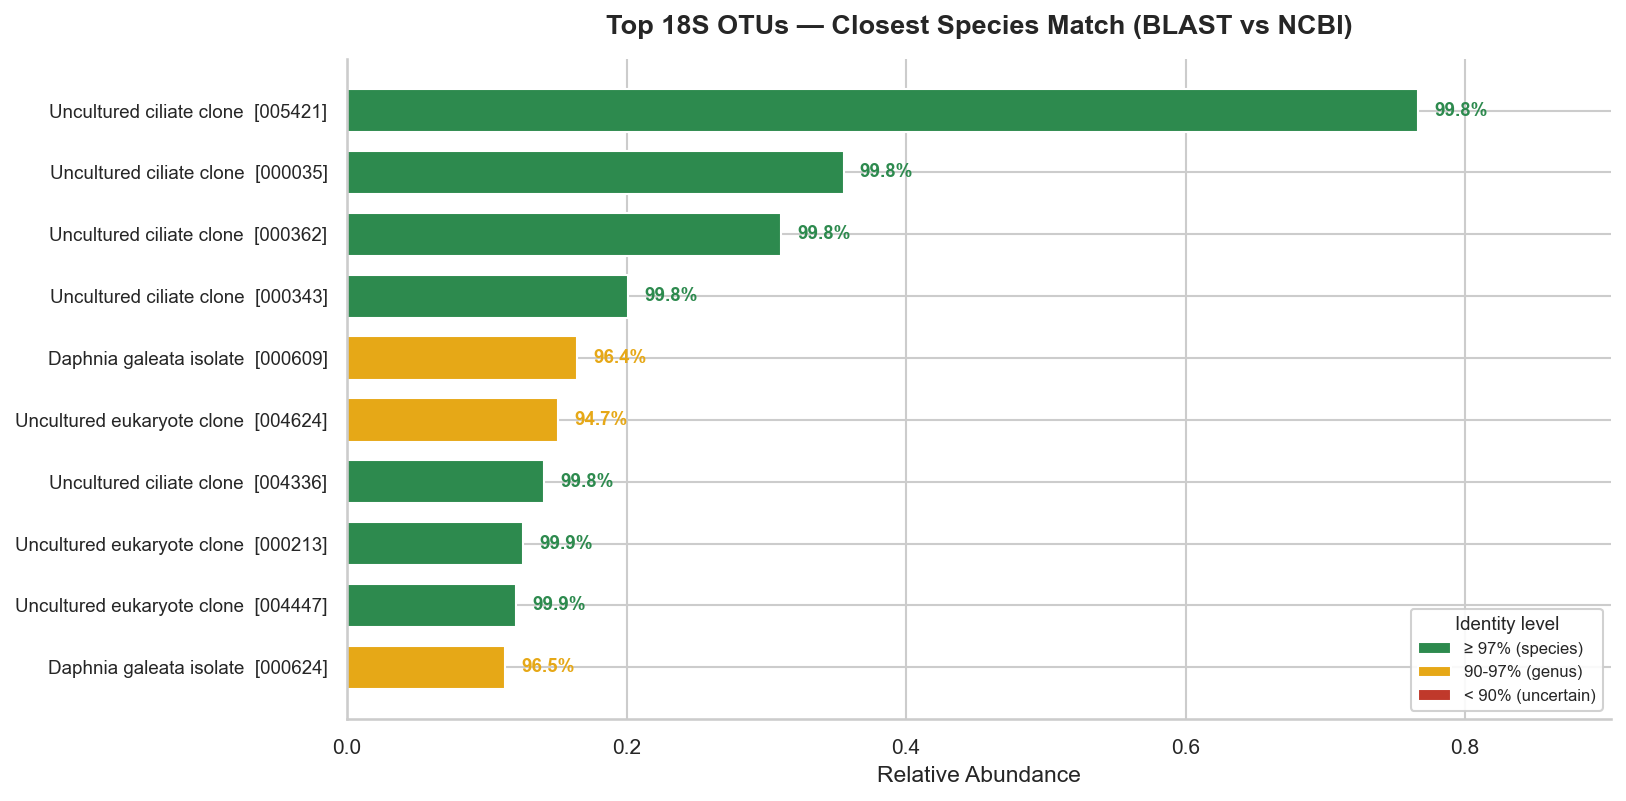

In [107]:
def parse_blast_file(filepath):
    """Parses the custom text output from script 6_blast_top_otus.py"""
    data = []
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        start_reading = False
        for line in lines:
            if line.startswith('---'):
                start_reading = True
                continue
            if not start_reading or not line.strip(): continue
            parts = line.split('|')
            if len(parts) >= 4:
                otu_id = parts[0].strip()
                species = parts[2].strip()
                identity_str = parts[3].strip().replace('%', '')
                try:
                    reads = float(parts[1].strip())
                    identity = float(identity_str) if identity_str and identity_str != '-' else None
                    data.append({'OTU': otu_id, 'Species': species, 'Abundance': reads, 'Identity': identity})
                except: continue
    except FileNotFoundError:
        print("BLAST file not found.")
        return pd.DataFrame()
    return pd.DataFrame(data)

df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_18S.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top 18S OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    plt.show()
else:
    print("No valid BLAST data found to plot.")

# Part B: COI Marker Biodiversity Analysis
*Objective: To characterize the metazoan community structure using the COI marker and investigate why it failed to detect the expected vertebrate (Fish) signals.*

**Technical Context:** A MIDORI2 COI reference database was used for SINTAX-based taxonomy assignment (vs. SILVA for 18S). Key differences between the databases:
* **Taxonomy format:** MIDORI2 appends NCBI taxon IDs to names (e.g., `Arthropoda_6656`) and uses rank prefixes (e.g., `phylum_Cryptophyceae`) — these are cleaned below.
* **Species resolution:** MIDORI2's SINTAX output provides only genus-level names in the species field (e.g., `s:Cyclops`) — 99.9% of COI "species" are identical to genus. True species-level identification requires BLAST.
* **Domain field:** MIDORI2 uses `k:` (kingdom) instead of `d:` (domain), so the `SILVA_Domain` column is empty for COI in the current pipeline output.
* Many assignments fell below the 0.8 confidence threshold, and only ~65% of OTUs received any taxonomy.

## B.1.a Broad Taxonomic Structure (COI)
This stacked bar chart visualizes the relative abundance of Phyla across all samples using the COI marker.
* **Expected Result:** If the COI primers worked well, we would expect to see **Chordata** (Fish) and **Arthropoda** (Invertebrates).
* **Reality Check:** Due to ciliate swamping and short-read issues, the actual composition may differ significantly from expectations.

In [108]:
# Load COI Data (already loaded as df_coi_raw above)
df_coi = df_coi_raw.copy()
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]

# Clean taxonomy labels (for MIDORI2: strip rank prefixes and NCBI IDs)
rank_prefixes = re.compile(r'^(kingdom|phylum|class|order|family|genus|species)_', re.IGNORECASE)
tax_levels_coi = [f'{prefix_coi}_{r}' for r in ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']]
for col in tax_levels_coi:
    if col in df_coi.columns:
        df_coi[col] = df_coi[col].apply(
            lambda x: rank_prefixes.sub('', str(x)) if pd.notna(x) else x
        )
        df_coi[col] = df_coi[col].apply(
            lambda x: '_'.join(str(x).rsplit('_', 1)[:-1])
            if pd.notna(x) and '_' in str(x) and str(x).rsplit('_', 1)[-1].isdigit()
            else x
        )

phylum_col_coi = f'{prefix_coi}_Phylum'

# Group by Phylum
# Confidence filter: blank low-confidence phylum assignments
_phylum_conf = f'{prefix_coi}_Phylum_Conf'
if _phylum_conf in df_coi.columns:
    df_coi.loc[pd.to_numeric(df_coi[_phylum_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, phylum_col_coi] = ''
df_coi[phylum_col_coi] = df_coi[phylum_col_coi].fillna('Unassigned')
phylum_coi = df_coi.groupby(phylum_col_coi)[sample_cols_coi].sum()

# Sort and Group "Others"
phylum_coi['Total'] = phylum_coi.sum(axis=1)
phylum_coi = phylum_coi.sort_values('Total', ascending=False)
top_phyla_coi = phylum_coi.head(10).index

plot_data_coi = phylum_coi.loc[top_phyla_coi].drop(columns='Total')
others_coi = phylum_coi.loc[~phylum_coi.index.isin(top_phyla_coi)].drop(columns='Total').sum()
plot_data_coi.loc['Others'] = others_coi

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plot_data_coi.columns = clean_sample_names(plot_data_coi.columns)
plot_data_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Lake Community Composition — Phylum (COI, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Sample ID')
ax.set_ylabel('Relative Abundance')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## B.1.b Class-Level Breakdown (COI)
**Objective:** To see which specific biological Classes dominate within the broad Phyla for the COI marker.

**Visual Analysis:**
1. **Actinopteri (Fish):** If present, ray-finned fish would validate the COI marker for aquatic vertebrates.
2. **Insecta:** The dominant arthropod Class — may indicate terrestrial contamination or genuine aquatic insect larvae.
3. **Sordariomycetes (Fungi):** Look for fungal classes that may indicate off-target amplification.

In [109]:
# Group by Class (COI)
class_col_coi = f'{prefix_coi}_Class'
# Confidence filter: blank low-confidence class assignments
_class_conf = f'{prefix_coi}_Class_Conf'
if _class_conf in df_coi.columns:
    df_coi.loc[pd.to_numeric(df_coi[_class_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, class_col_coi] = ''
df_coi[class_col_coi] = df_coi[class_col_coi].fillna('Unassigned')
class_coi = df_coi.groupby(class_col_coi)[sample_cols_coi].sum()
class_coi = class_coi.drop('Unassigned', errors='ignore')

# Sort and Top 15
class_coi['Total'] = class_coi.sum(axis=1)
class_coi = class_coi.sort_values('Total', ascending=False)
top_classes_coi = class_coi.head(15).index

# Prepare Data
plot_cls_coi = class_coi.loc[top_classes_coi].drop(columns='Total')
others_cls_coi = class_coi.loc[~class_coi.index.isin(top_classes_coi)].drop(columns='Total').sum()
plot_cls_coi.loc['Others'] = others_cls_coi

# Custom color logic
num_colors_coi = len(plot_cls_coi)
colors_coi = cm.tab20(np.linspace(0, 1, num_colors_coi))
custom_colors_coi = []
for i, cls_name in enumerate(plot_cls_coi.index):
    if cls_name == 'Unassigned':
        custom_colors_coi.append('#D3D3D3')
    elif cls_name == 'Others':
        custom_colors_coi.append('#696969')
    else:
        custom_colors_coi.append(colors_coi[i])

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
plot_cls_coi.columns = clean_sample_names(plot_cls_coi.columns)
plot_cls_coi = plot_cls_coi.div(plot_cls_coi.sum(axis=0), axis=1) * 100  # normalize to %
plot_cls_coi = plot_cls_coi.fillna(0)
plot_cls_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=custom_colors_coi)

ax.set_title(f'Class-Level Composition (COI, {prefix_coi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), bbox_to_anchor=(1.02, 1), loc='upper left', title='Class')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_cls_coi.columns):
    if plot_cls_coi[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## B.2 Order-Level Breakdown (COI)
Order-level community composition for COI marker.

In [110]:
order_col_coi = f'{prefix_coi}_Order'
# Confidence filter: blank low-confidence order assignments
_order_conf = f'{prefix_coi}_Order_Conf'
if _order_conf in df_coi.columns:
    df_coi.loc[pd.to_numeric(df_coi[_order_conf], errors='coerce').fillna(0) < CONF_THRESHOLD, order_col_coi] = ''
df_coi[order_col_coi] = df_coi[order_col_coi].fillna('Unassigned')
order_coi = df_coi.groupby(order_col_coi)[sample_cols_coi].sum()
order_coi = order_coi.drop('Unassigned', errors='ignore')

order_coi['Total'] = order_coi.sum(axis=1)
order_coi = order_coi.sort_values('Total', ascending=False)
top_orders_coi = order_coi.head(15).index

plot_ord_coi = order_coi.loc[top_orders_coi].drop(columns='Total')
others_ord_coi = order_coi.loc[~order_coi.index.isin(top_orders_coi)].drop(columns='Total').sum()
plot_ord_coi.loc['Others'] = others_ord_coi

fig, ax = plt.subplots(figsize=(12, 7))
plot_ord_coi.columns = clean_sample_names(plot_ord_coi.columns)
plot_ord_coi = plot_ord_coi.div(plot_ord_coi.sum(axis=0), axis=1) * 100  # normalize to %
plot_ord_coi = plot_ord_coi.fillna(0)
plot_ord_coi.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, cmap='tab20')

ax.set_title(f'Order-Level Composition (COI, {prefix_coi})', fontweight='bold')
ax.set_ylabel('Relative Abundance (%)')
ax.legend(title='Order', bbox_to_anchor=(1.02, 1), loc='upper left')

# Mark samples with no assigned taxa
for _idx, _sample in enumerate(plot_ord_coi.columns):
    if plot_ord_coi[_sample].sum() == 0:
        ax.text(_idx, 2, 'ND', ha='center', va='bottom',
                fontsize=9, color='gray', fontstyle='italic')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## B.3 Genus-Level Top 20 (COI)
Top genera detected by the COI marker with confidence annotations.

In [ ]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_coi[genus_col] = df_coi[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_coi.columns:
    mask_conf = pd.to_numeric(df_coi[conf_col], errors='coerce') >= 0.8
    df_conf = df_coi[mask_conf].copy()
else:
    df_conf = df_coi[df_coi[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_coi].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.sum(axis=1)
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (COI, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Total Abundance')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

### Top 20 Genera by Abundance — All Confidences (COI)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

In [ ]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_tmp = df_coi.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_coi].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.sum(axis=1)
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Total Abundance', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (COI, {prefix_coi})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## B.4 Taxonomic Resolution Comparison: 18S vs COI
Compare taxonomic resolution between both markers.

In [112]:
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

levels_18s = [f'{prefix_18s}_{r}' for r in ranks]
unassigned_18s = []
for level in levels_18s:
    conf_level = level + '_Conf'
    no_taxonomy = df_18s[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_18s[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_18s.columns else pd.Series(False, index=df_18s.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_18s.append(pct)

levels_coi = [f'{prefix_coi}_{r}' for r in ranks]
unassigned_coi = []
for level in levels_coi:
    conf_level = level + '_Conf'
    no_taxonomy = df_coi[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_coi[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_coi.columns else pd.Series(False, index=df_coi.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_coi)) * 100
    unassigned_coi.append(pct)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ranks))
width = 0.35

bars1 = ax.bar(x - width/2, unassigned_18s, width, label=f'18S ({prefix_18s})', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, unassigned_coi, width, label=f'COI ({prefix_coi})', color='steelblue', alpha=0.8)

ax.set_title(f'Taxonomic Resolution Decay: 18S ({prefix_18s}) vs COI ({prefix_coi})', fontweight='bold')
ax.set_ylabel('% of OTUs Unassigned')
ax.set_xticks(x)
ax.set_xticklabels(ranks, rotation=45)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## B.4 The "Unassigned" Reality Check (COI)
**Comparison with 18S:** We expect the COI marker to have a significantly higher "Unassigned" rate than 18S at every taxonomic level, due to the combination of:
1. Lower sequencing depth (after short-read filtering)
2. The strict 0.8 confidence threshold applied to SINTAX assignments
3. Potential database gaps in the MIDORI2 COI reference

In [113]:
# Calculate % Unassigned at each level (COI)
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
levels_coi = [f'{prefix_coi}_{r}' for r in ranks]
unassigned_counts_coi = []

for level in levels_coi:
    conf_level = level + '_Conf'
    no_taxonomy = df_coi[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_coi[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_coi.columns else pd.Series(False, index=df_coi.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_coi)) * 100
    unassigned_counts_coi.append(pct)

# Recalculate 18S unassigned for comparison
levels_18s = [f'{prefix_18s}_{r}' for r in ranks]
unassigned_18s = []
for level in levels_18s:
    conf_level = level + '_Conf'
    no_taxonomy = df_18s[level].isin(['Unassigned', '', np.nan])
    low_conf = pd.to_numeric(df_18s[conf_level], errors='coerce').fillna(0) < CONF_THRESHOLD if conf_level in df_18s.columns else pd.Series(False, index=df_18s.index)
    n_unassigned = (no_taxonomy | low_conf).sum()
    pct = (n_unassigned / len(df_18s)) * 100
    unassigned_18s.append(pct)

# Plot: side-by-side comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(ranks))
width = 0.35

bars1 = ax.bar(x - width/2, unassigned_18s, width, label=f'18S ({prefix_18s})', color='salmon', alpha=0.8)
bars2 = ax.bar(x + width/2, unassigned_counts_coi, width, label=f'COI ({prefix_coi})', color='steelblue', alpha=0.8)

ax.set_title('Taxonomic Resolution Decay: 18S vs COI', fontweight='bold')
ax.set_ylabel('% of OTUs Unassigned')
ax.set_xticks(x)
ax.set_xticklabels(ranks, rotation=45)
ax.set_ylim(0, 100)
ax.legend()

plt.tight_layout()
plt.show()

## B.5 Forensics: Manual BLAST Identification
The plot below proves that the COI failure was specific, not random.
1.  **Ciliates (Uncultured ciliate):** The primers accidentally amplified the same organisms we found in the 18S dataset.
2.  **Daphnia Success:** We *did* find *Daphnia galeata*!

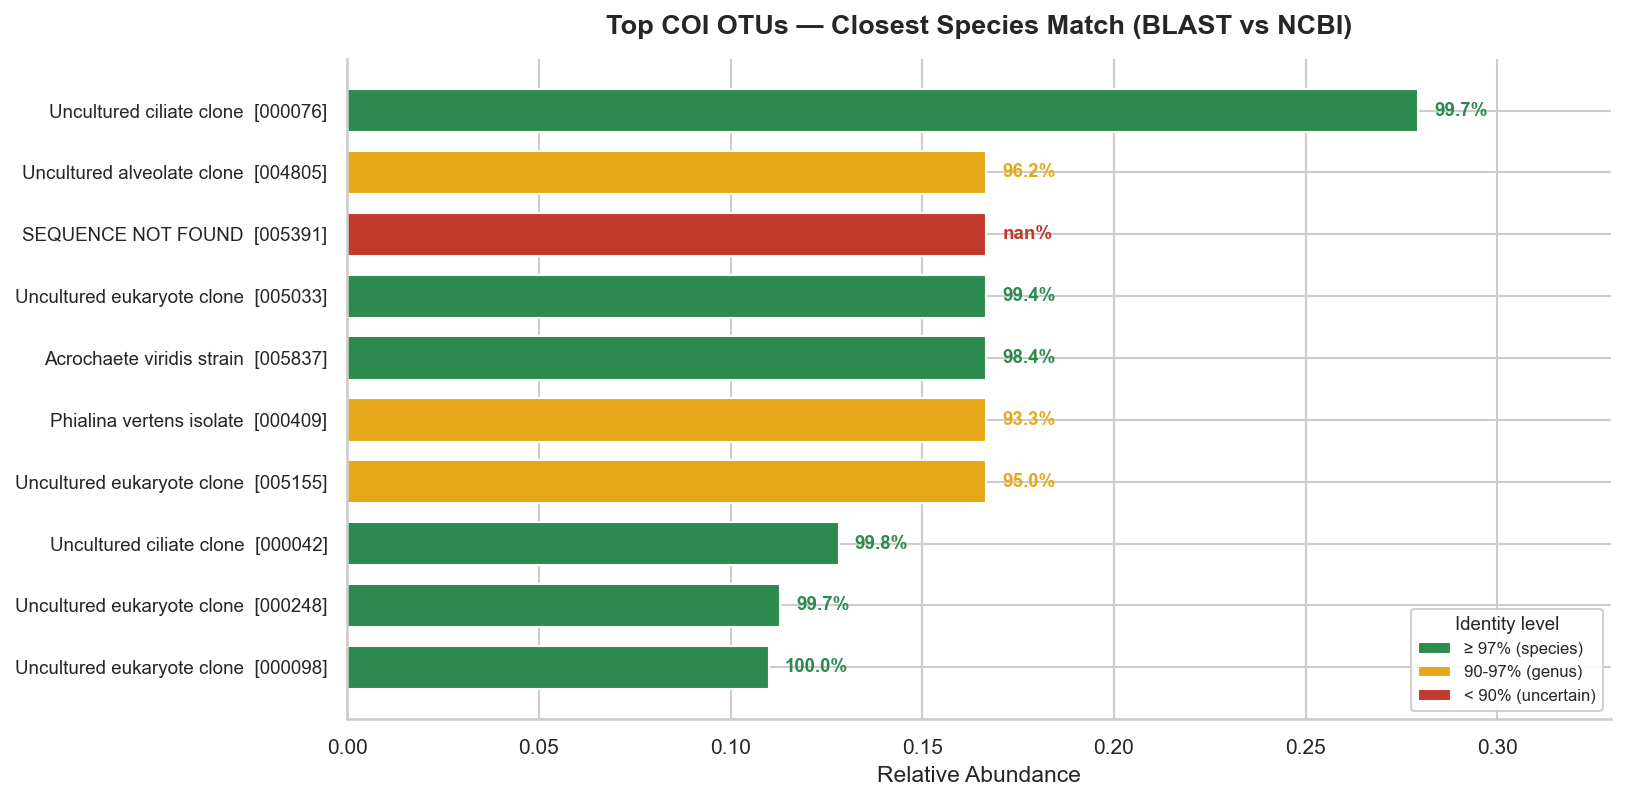

In [114]:
df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_COI.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top COI OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    plt.show()
else:
    print("No valid BLAST data found to plot.")

---
## Part C: Non-Metazoan Detections (COI)
Examine non-metazoan eukaryotes detected by the COI marker.

In [115]:
class_col = f'{prefix_coi}_Class'
phylum_col = f'{prefix_coi}_Phylum'
genus_col = f'{prefix_coi}_Genus'

# Non-metazoan = Class is not Metazoa and not empty/Unassigned
# Confidence filter: only use OTUs with confident class assignment
_class_conf_nm = f'{prefix_coi}_Class_Conf'
if _class_conf_nm in df_coi.columns:
    _conf_mask = pd.to_numeric(df_coi[_class_conf_nm], errors='coerce').fillna(0) >= CONF_THRESHOLD
    df_coi_conf = df_coi[_conf_mask].copy()
else:
    df_coi_conf = df_coi.copy()

non_metazoan = df_coi_conf[
    (~df_coi[class_col].isin(['Metazoa', 'Unassigned', '', np.nan])) &
    (df_coi[class_col].notna())
]

if len(non_metazoan) > 0:
    print(f"Non-Metazoan COI OTUs: {len(non_metazoan)} ({100*len(non_metazoan)/len(df_coi):.1f}% of total)")
    print(f"\nNon-Metazoan Classes:")

    non_meta_class = non_metazoan.groupby(class_col)[sample_cols_coi].sum()
    non_meta_class['Total'] = non_meta_class.sum(axis=1)
    non_meta_class = non_meta_class.sort_values('Total', ascending=False)
    for cls, row in non_meta_class.iterrows():
        print(f"  {cls}: {row['Total']:.4f}")

    print(f"\nTop 10 non-Metazoan Genera:")
    non_meta_genus = non_metazoan.groupby(genus_col)[sample_cols_coi].sum()
    non_meta_genus['Total'] = non_meta_genus.sum(axis=1)
    non_meta_genus = non_meta_genus.sort_values('Total', ascending=False)
    for gen, row in non_meta_genus.head(10).iterrows():
        print(f"  {gen}: {row['Total']:.4f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(x=non_meta_class['Total'], y=non_meta_class.index, palette='Set2', ax=ax)
    ax.set_title(f'Non-Metazoan COI Detections ({prefix_coi})', fontweight='bold')
    ax.set_xlabel('Total Abundance')
    ax.set_ylabel('Class')
    plt.tight_layout()
    plt.show()
else:
    print("No non-Metazoan OTUs detected in COI")

---
## Part D: Cross-Marker Comparison (18S vs COI)
Compare the taxonomic profiles from both markers.

In [116]:
# Compare genus-level detections between 18S and COI
genus_col_18s = f'{prefix_18s}_Genus'
genus_col_coi = f'{prefix_coi}_Genus'

# Only include genera with confidence >= threshold
_g_conf_18s = f'{prefix_18s}_Genus_Conf'
if _g_conf_18s in df_18s.columns:
    _mask_18s = pd.to_numeric(df_18s[_g_conf_18s], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_18s_g = df_18s[_mask_18s]
else:
    _df_18s_g = df_18s
genera_18s = set(_df_18s_g[genus_col_18s].dropna().unique()) - {'Unassigned', ''}
_g_conf_coi = f'{prefix_coi}_Genus_Conf'
if _g_conf_coi in df_coi.columns:
    _mask_coi = pd.to_numeric(df_coi[_g_conf_coi], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_coi_g = df_coi[_mask_coi]
else:
    _df_coi_g = df_coi
genera_coi = set(_df_coi_g[genus_col_coi].dropna().unique()) - {'Unassigned', ''}

shared = genera_18s & genera_coi
only_18s = genera_18s - genera_coi
only_coi = genera_coi - genera_18s

print(f"Genera detected by 18S ({prefix_18s}): {len(genera_18s)}")
print(f"Genera detected by COI ({prefix_coi}):  {len(genera_coi)}")
print(f"Shared genera:                  {len(shared)}")
print(f"Only in 18S:                    {len(only_18s)}")
print(f"Only in COI:                    {len(only_coi)}")

if shared:
    print(f"\nShared genera (first 20): {sorted(shared)[:20]}")

## B.6 Diagnosis of COI Failure
**Root Cause Analysis:**
The failure of the COI marker appears to be a two-fold technical issue:

1.  **Primary Failure: Short Fragment Amplification**
    * **Observation:** The vast majority (>90%) of raw COI reads were **<300bp** (see Section D).
    * **Cause:** This indicates the preferential amplification of **Primer Dimers** or highly degraded DNA fragments. The size selection step (Step 2) correctly discarded these, but it left us with very low sequencing depth for the actual analysis.

2.  **Secondary Failure: Ciliate Swamping**
    * **Observation:** Of the reads that *did* pass the size filter, BLAST analysis (plot above) identifies them largely as **Uncultured Ciliates**.
    * **Cause:** The primers lacked specificity for Metazoa, allowing the abundant microbial loop DNA (which we saw in the 18S results) to out-compete the rare fish DNA.

**Future Work:**
* Test a less strict size selection threshold to retain more reads.
* Might also consider that the COI primers need to be redesigned?

## Part C: Computational Costs
**Summary:**
* **Total Time:** ~42 minutes on a 12-core laptop.
* **The Bottleneck:** Clustering (Step 3) took 54% of the time. This `NxN` comparison is computationally expensive and would require a supercomputer for larger datasets.
* **Efficiency:** The "Preprocessing" step was fast because it runs in parallel. The "BLAST" step was slow because we had to wait 3 seconds between requests to respect NCBI limits.

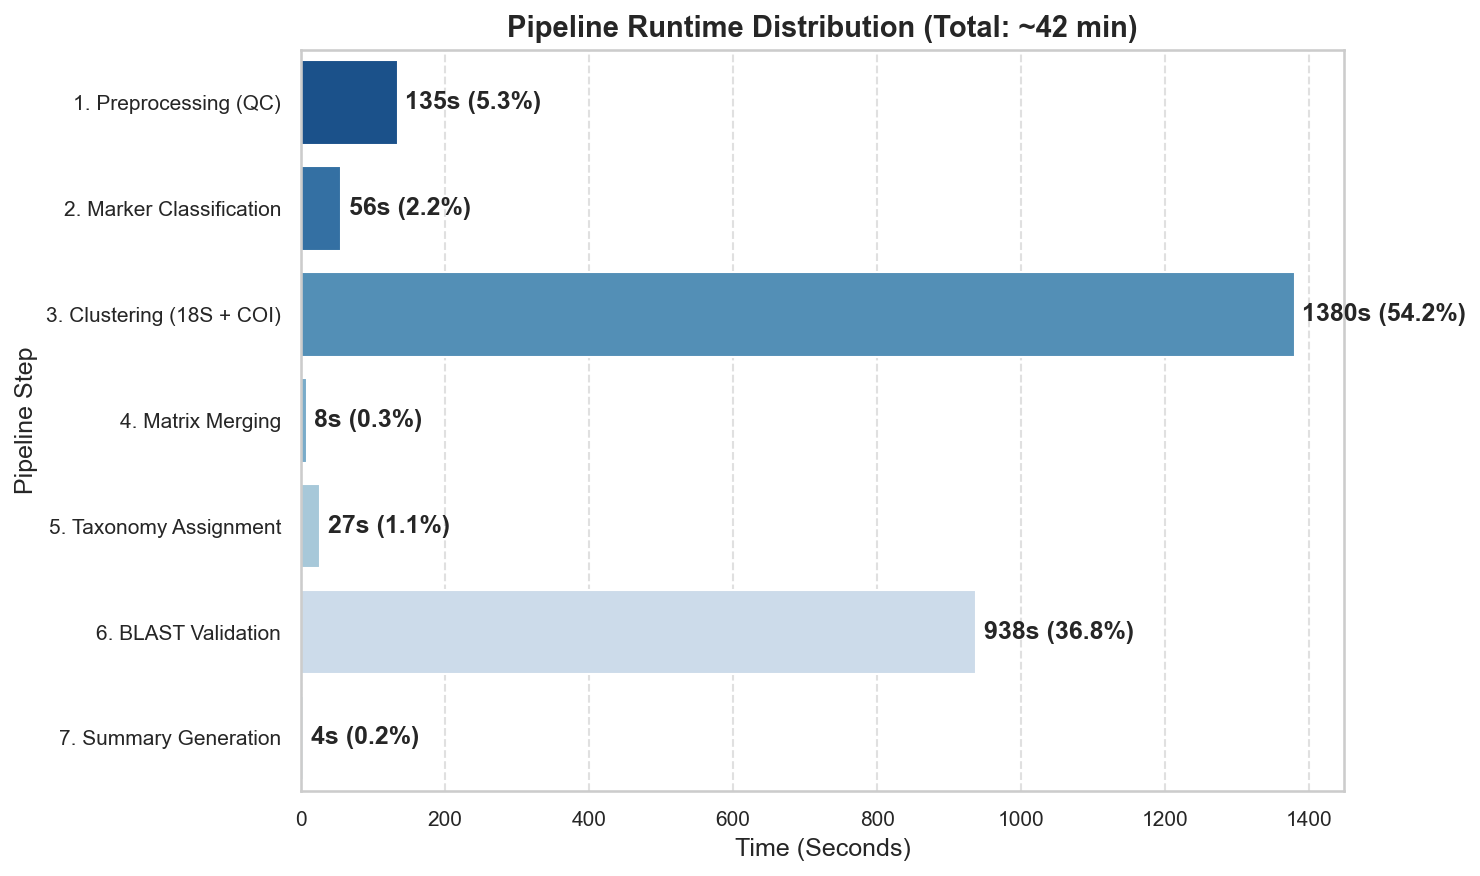

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted manually from log file
timing_data = {
    'Step': [
        '1. Preprocessing (QC)', 
        '2. Marker Classification', 
        '3. Clustering (18S + COI)', 
        '4. Matrix Merging', 
        '5. Taxonomy Assignment', 
        '6. BLAST Validation', 
        '7. Summary Generation'
    ],
    'Time_Seconds': [
        135,   # Preprocessing
        56,    # Classification
        1380,  # Clustering (The bottleneck!)
        8,     # Merging
        27,    # Taxonomy
        938,   # BLAST (Top 10 only)
        4      # Summary
    ]
}

df_time = pd.DataFrame(timing_data)

# Calculate percentages
total_time = df_time['Time_Seconds'].sum()
df_time['Percentage'] = (df_time['Time_Seconds'] / total_time) * 100

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x='Time_Seconds', y='Step', data=df_time, hue='Step', palette='Blues_r', ax=ax, legend=False)

# Add annotations
for i, v in enumerate(df_time['Time_Seconds']):
    pct = df_time.loc[i, 'Percentage']
    ax.text(v + 10, i, f"{int(v)}s ({pct:.1f}%)", va='center', fontweight='bold')

ax.set_title('Pipeline Runtime Distribution (Total: ~42 min)', fontweight='bold')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Pipeline Step')
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Global confidence threshold for taxonomy filtering
CONF_THRESHOLD = 0.8

# Part D: Methodological Defense & Improvements

### 1. Error Correction Strategy
* **Problem:** Nanopore sequencing has a raw error rate of ~5-10%.
* **Solution:** We used **95% Identity Clustering**.
    * *Why?* Clustering at 97% or 99% (typical for Illumina) would have resulted in millions of false OTUs because every sequencing error would look like a new species.

### 2. Size Selection
* **18S Filter:** We discarded reads > 3000bp.
    * *Why?* The target 18S V4-V9 region is ~1800bp. Reads longer than 3kb are likely **Genomic Concatemers** (two molecules stuck together during library prep) or **Chimeras**. Including them would skew abundance counts.
* **COI Filter:** We enforced a range of 300-1000bp.
    * *Observation:* Many reads were <300bp. These were identified as fragmented 18S sequences or primer-dimers, which we successfully filtered out before clustering.

### 3. Computational Cost
* **Bottleneck:** The VSEARCH clustering step ($N \times N$ comparison) took >50% of the total runtime (~20 mins).

### 4. Critical Requirement: Custom Reference Database Construction
* **The Problem:** We relied on general-purpose databases (SILVA) which failed for our specific needs:
    * **18S Failure:** SILVA lacks local Swiss terrestrial arthropods, leading to "Exotic" misidentifications (*Frieseomelitta*).
    * **For COI:** We need to find a correct reference database. I tried with MIDORI but did not find how to build the db properly.
* **The Solution (Future Work):** A custom, curated database is required.
    * **Action Item:** We must build a **"Lake Leman Specific" database**. This involves downloading sequences for all known local species (Fish, Mussels, Insects, Plankton) from NCBI and formatting them specifically for SINTAX (in order to use VSEARCH).
    * **Benefit:** This would eliminate the "Brazilian Bee" artifacts and allow for accurate species-level identification of local biodiversity.

### 5. COI Marker Optimization
* A lot (>90%)of reads were very short (<300bp) and were discarded. We should investigate intermediate files.



## For COI (Water + Soil — both JEDI & standard)

### 1. BOLD Systems (boldsystems.org) — **Best option**
- **17M+ COI barcodes**, the largest curated COI database in the world
- Strong coverage of **European freshwater invertebrates** and **soil arthropods**
- Species-level BIN (Barcode Index Number) system for reliable identification
- Has an API for batch identification
- Your pipeline could query BOLD directly instead of relying on MIDORI2/NCBI BLAST

### 2. Porter CO1 Classifier v5.1.0 (github.com/terrimporter/CO1Classifier)
- **2.2M COI sequences** from 236K taxa (185K species)
- **Pre-formatted for SINTAX/VSEARCH** — drop-in replacement for your MIDORI2 `.udb`
- Based on GenBank + BOLD combined, much more comprehensive than MIDORI2 alone
- Validated accuracy with bootstrap cutoffs
- Direct download: `SINTAX_COIv5.0.0.zip` from releases

### 3. eKOI (from PR2 ecosystem, 2025) — **New, protist-focused**
- Specifically designed for **eukaryotic COI** including protists
- Would help correctly identify the ciliates/diatoms that are dominating your samples instead of misclassifying them as insects
- Published in *Database* journal 2025

---

## For 18S (Water)

### 4. PR2 Database v5.1 (pr2-database.org) — **Best for protists/plankton**
- **220K+ 18S sequences** with expert-curated taxonomy
- Excellent for **ciliates, diatoms, and other protists** — exactly what dominates your water samples
- 9-level taxonomy with consistent annotation
- Available in SINTAX format — compatible with your VSEARCH pipeline
- Would resolve many of your "Unassigned" ciliates that SILVA misses

### 5. Porter 18S Classifier v4.1 (github.com/terrimporter/18SClassifier)
- Based on SILVA 138 but reformatted for RDP classifier
- Better for broad eukaryote classification
- Less useful than PR2 for your protist-heavy samples

---

## For Soil Diatoms specifically

### 6. Diat.barcode / R-Syst::diatom (github.com/terrimporter/SSUdiatomClassifier)
- Curated SSU database specifically for **diatoms**
- Since *Surirella* and other diatoms dominate your soil COI results, this would help validate those signals via the 18S marker

---

## Recommended Strategy

| Marker | Current DB | **Recommended Replacement** | Why |
|---|---|---|---|
| 18S (Water) | SILVA v123 | **PR2 v5.1** | Expert-curated protist taxonomy, SINTAX-compatible |
| COI (Water) | MIDORI2 | **Porter CO1 v5.1 + BOLD** | 4x more sequences, SINTAX-ready, better coverage |
| JEDI/COI (Soil) | MIDORI2 | **Porter CO1 v5.1 + BOLD** | Same, plus add eKOI for the protist/diatom signal |

The **Porter CO1 v5.1** is the easiest win — it's a direct drop-in for your VSEARCH SINTAX step and would immediately improve assignments. For 18S, switching from SILVA to **PR2** would dramatically improve your ciliate/plankton classifications.